# Per-Gene MLP Probing Results Analysis

**Experiment:** 400 genes (top coverage) from CRC, each trained with a separate MLP(768→1)  
**Features:** Frozen MorphPT embeddings (original classification checkpoint)  
**Split:** Spatial split  
**Question:** Can frozen MorphPT morphological features predict gene expression without any fine-tuning?

**Sections:**
1. Load & collect all results
2. Overall performance summary
3. Performance by coverage bin
4. Distribution of Pearson r
5. Top & bottom genes
6. Coverage vs Pearson r scatter
7. Comparison with multi-output model (if available)

## 1. Setup & Load Results

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats

PROJECT  = Path('/hpc/group/jilab/tc459/MorphPT')

# ── Adjust these paths if needed ──────────────────────────────────────────
MLP_EXP_DIR = PROJECT / 'experiments/mlp_probing_crc'   # per-gene MLP results
GENE_CSV    = PROJECT / 'cache_crc/per_gene/top400_genes_by_coverage.csv'
MULTI_DIR   = PROJECT / 'experiments/visium_morphpt_lora_10x_mlp_crc_randsplit'  # multi-output baseline

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
})
print('Setup done.')

Setup done.


In [14]:
def collect_mlp_results(exp_dir):
    rows = []
    
    # ← Change glob pattern to match gene name folders directly
    for d in sorted(exp_dir.iterdir()):
        if not d.is_dir():
            continue
            
        for fname in ['results.json', 'result.json']:
            f = d / fname
            if f.exists():
                r = json.loads(f.read_text())
                rows.append({
                    'gene_name':  r.get('gene_name', d.name),
                    'gene_idx':   r.get('gene_idx', -1),
                    'test_r':     r.get('test_pearson',
                                       r.get('test_r', 0)),
                    'val_r':      r.get('best_val_pearson',
                                       r.get('val_r', 0)),
                    'total_time': r.get('total_time_sec', None),
                })
                break
    
    return pd.DataFrame(rows)

# Load results
df = collect_mlp_results(MLP_EXP_DIR)

# Load gene coverage info
gene_df = pd.read_csv(GENE_CSV)

# Merge coverage into results
df = df.merge(gene_df[['gene_name', 'coverage', 'rank']],
              on='gene_name', how='left')

print(f'Total genes in CSV  : {len(gene_df)}')
print(f'Results collected   : {len(df)}')
print(f'Missing             : {len(gene_df) - len(df)}')

if len(df) > 0:
    print(f'\nSample results:')
    print(df.head(5)[['gene_name', 'coverage', 'test_r', 'val_r']].to_string(index=False))

Total genes in CSV  : 400
Results collected   : 400
Missing             : 0

Sample results:
gene_name  coverage   test_r    val_r
    ACSL5  0.342503 0.310309 0.302599
     ACTB  0.831378 0.250053 0.307963
    ACTG1  0.517022 0.271986 0.261306
    ACTN1  0.281111 0.135819 0.121946
     ADI1  0.248876 0.199617 0.185853


## 2. Overall Performance Summary

In [15]:
if len(df) == 0:
    print('No results found. Check MLP_EXP_DIR path.')
else:
    print('=' * 55)
    print('PER-GENE MLP PROBING — CRC (Frozen MorphPT Features)')
    print('=' * 55)
    print(f'Genes completed     : {len(df)} / {len(gene_df)}')
    print(f'mean  Pearson r     : {df["test_r"].mean():.4f}')
    print(f'median Pearson r    : {df["test_r"].median():.4f}')
    print(f'std   Pearson r     : {df["test_r"].std():.4f}')
    print(f'min   Pearson r     : {df["test_r"].min():.4f}')
    print(f'max   Pearson r     : {df["test_r"].max():.4f}')
    print()
    print(f'r > 0.0  : {(df["test_r"] > 0.0).sum():>4} / {len(df)}  ({(df["test_r"] > 0.0).mean():.1%})')
    print(f'r > 0.1  : {(df["test_r"] > 0.1).sum():>4} / {len(df)}  ({(df["test_r"] > 0.1).mean():.1%})')
    print(f'r > 0.2  : {(df["test_r"] > 0.2).sum():>4} / {len(df)}  ({(df["test_r"] > 0.2).mean():.1%})')
    print(f'r > 0.3  : {(df["test_r"] > 0.3).sum():>4} / {len(df)}  ({(df["test_r"] > 0.3).mean():.1%})')
    print(f'r > 0.5  : {(df["test_r"] > 0.5).sum():>4} / {len(df)}  ({(df["test_r"] > 0.5).mean():.1%})')
    
    # Val vs test gap
    print(f'\nVal/Test correlation:')
    if 'val_r' in df.columns:
        gap = (df['val_r'] - df['test_r']).mean()
        print(f'  mean val_r  : {df["val_r"].mean():.4f}')
        print(f'  mean test_r : {df["test_r"].mean():.4f}')
        print(f'  gap (val-test): {gap:+.4f}')

PER-GENE MLP PROBING — CRC (Frozen MorphPT Features)
Genes completed     : 400 / 400
mean  Pearson r     : 0.2454
median Pearson r    : 0.2274
std   Pearson r     : 0.1117
min   Pearson r     : 0.0492
max   Pearson r     : 0.7805

r > 0.0  :  400 / 400  (100.0%)
r > 0.1  :  383 / 400  (95.8%)
r > 0.2  :  258 / 400  (64.5%)
r > 0.3  :   91 / 400  (22.8%)
r > 0.5  :   12 / 400  (3.0%)

Val/Test correlation:
  mean val_r  : 0.2154
  mean test_r : 0.2454
  gap (val-test): -0.0301


## 3. Performance by Coverage Bin

In [16]:
bins   = [0, 0.20, 0.30, 0.50, 1.01]
blabels= ['<20%', '20-30%', '30-50%', '>50%']

print(f"{'Coverage bin':<12} {'n':>5} {'mean_r':>8} {'median_r':>10} {'r>0.2':>8} {'r>0.3':>8}")
print('-' * 58)

for i in range(len(blabels)):
    mask = (df['coverage'] >= bins[i]) & (df['coverage'] < bins[i+1])
    sub  = df[mask]
    if len(sub) == 0:
        continue
    print(f"{blabels[i]:<12} {len(sub):>5} "
          f"{sub['test_r'].mean():>8.4f} "
          f"{sub['test_r'].median():>10.4f} "
          f"{(sub['test_r']>0.2).sum():>8} "
          f"{(sub['test_r']>0.3).sum():>8}")

print('-' * 58)
print(f"{'All':<12} {len(df):>5} "
      f"{df['test_r'].mean():>8.4f} "
      f"{df['test_r'].median():>10.4f} "
      f"{(df['test_r']>0.2).sum():>8} "
      f"{(df['test_r']>0.3).sum():>8}")

Coverage bin     n   mean_r   median_r    r>0.2    r>0.3
----------------------------------------------------------
20-30%         234   0.2053     0.2053      124       18
30-50%         128   0.2671     0.2554       97       44
>50%            38   0.4200     0.4208       37       29
----------------------------------------------------------
All            400   0.2454     0.2274      258       91


## 4. Distribution of Pearson r

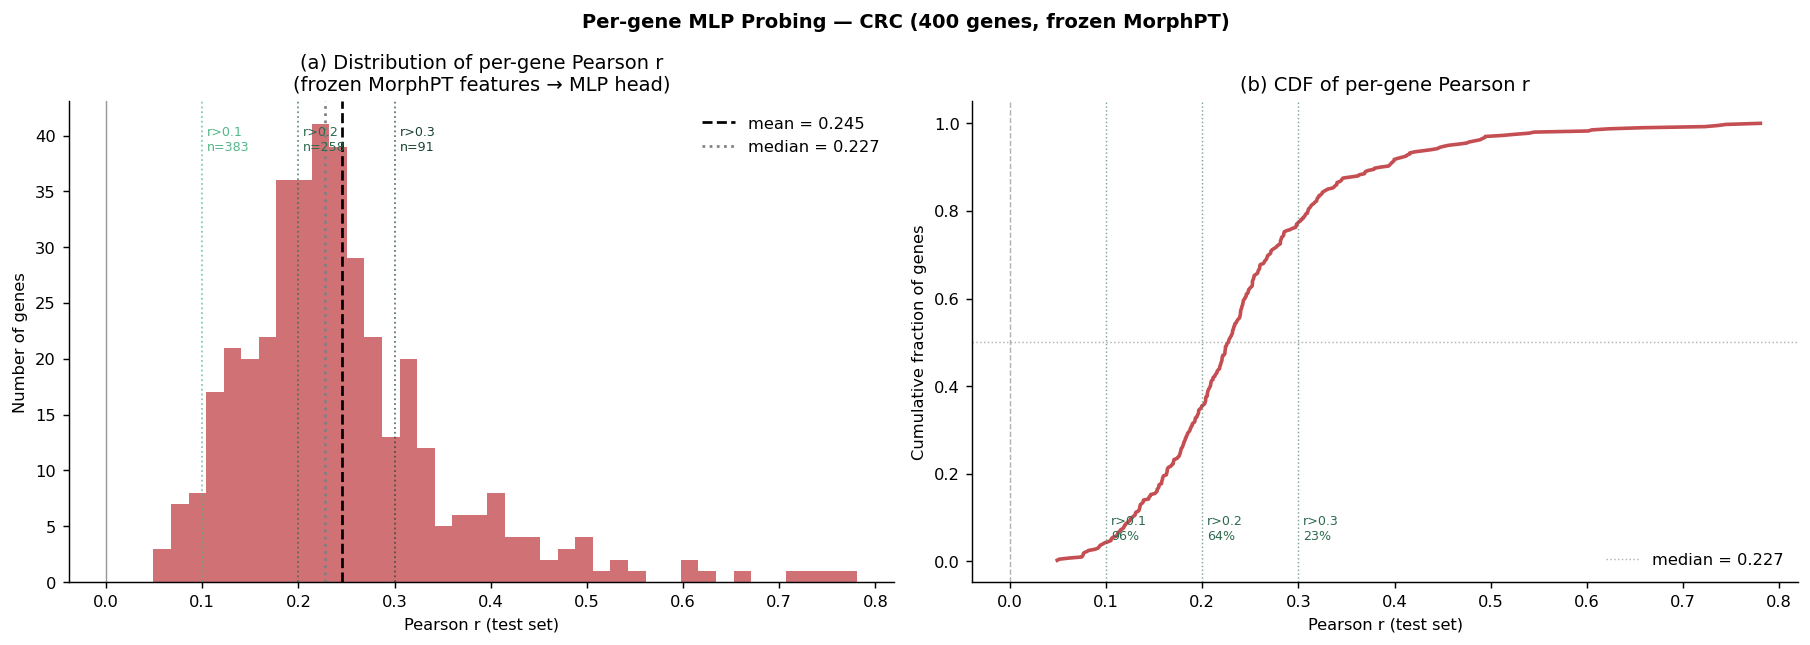

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Histogram
ax = axes[0]
ax.hist(df['test_r'], bins=40, color='#C44E52', alpha=0.8, edgecolor='none')
ax.axvline(df['test_r'].mean(),
           color='black', lw=1.5, ls='--',
           label=f'mean = {df["test_r"].mean():.3f}')
ax.axvline(df['test_r'].median(),
           color='gray', lw=1.5, ls=':',
           label=f'median = {df["test_r"].median():.3f}')
ax.axvline(0, color='black', lw=0.8, alpha=0.4)
ax.set_xlabel('Pearson r (test set)')
ax.set_ylabel('Number of genes')
ax.set_title('(a) Distribution of per-gene Pearson r\n'
             '(frozen MorphPT features → MLP head)')
ax.legend()

# Add tier annotations
for thr, col, lbl in [(0.1, '#52b788', 'r>0.1'),
                       (0.2, '#2d6a4f', 'r>0.2'),
                       (0.3, '#1b4332', 'r>0.3')]:
    n = (df['test_r'] > thr).sum()
    ax.axvline(thr, color=col, lw=1, ls=':', alpha=0.7)
    ax.text(thr + 0.005, ax.get_ylim()[1] * 0.95,
            f'{lbl}\nn={n}', fontsize=7, color=col, va='top')

# (b) Cumulative distribution
ax = axes[1]
sorted_r = np.sort(df['test_r'].values)
cdf      = np.arange(1, len(sorted_r)+1) / len(sorted_r)
ax.plot(sorted_r, cdf, color='#C44E52', lw=2)
ax.axvline(0,   color='gray',    lw=0.8, ls='--', alpha=0.6)
ax.axhline(0.5, color='gray',    lw=0.8, ls=':',  alpha=0.6,
           label=f'median = {df["test_r"].median():.3f}')
for thr in [0.1, 0.2, 0.3]:
    pct = (df['test_r'] > thr).mean()
    ax.axvline(thr, color='#2d6a4f', lw=0.8, ls=':', alpha=0.6)
    ax.text(thr + 0.005, 0.05,
            f'r>{thr}\n{pct:.0%}', fontsize=7, color='#2d6a4f')
ax.set_xlabel('Pearson r (test set)')
ax.set_ylabel('Cumulative fraction of genes')
ax.set_title('(b) CDF of per-gene Pearson r')
ax.legend()

fig.suptitle('Per-gene MLP Probing — CRC (400 genes, frozen MorphPT)',
             fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Top & Bottom Genes

In [20]:
print('TOP 50 best predicted genes:')
top20 = df.nlargest(50, 'test_r')[['rank', 'gene_name', 'coverage', 'test_r', 'val_r']]
print(top20.to_string(index=False))

print('\nBOTTOM 20 worst predicted genes:')
bot20 = df.nsmallest(20, 'test_r')[['rank', 'gene_name', 'coverage', 'test_r', 'val_r']]
print(bot20.to_string(index=False))

TOP 50 best predicted genes:
 rank gene_name  coverage   test_r    val_r
  187       VIM  0.290312 0.780515 0.759882
   11   CEACAM5  0.742925 0.744828 0.680951
   16   CEACAM6  0.691534 0.736064 0.624042
  260    COL3A1  0.258761 0.722873 0.773559
   15     MUC12  0.704499 0.658171 0.604726
   89      IGKC  0.359325 0.623053 0.271846
   17     EPCAM  0.685906 0.605003 0.529666
   19      PYGB  0.656712 0.601571 0.552387
    3    MT-ND4  0.967164 0.545497 0.508991
  110      LCN2  0.333410 0.539731 0.226040
   24      ST14  0.583957 0.525400 0.476490
    2   MT-ATP6  0.967695 0.512900 0.500800
    5    MT-CO2  0.897235 0.494350 0.484499
   28      KRT8  0.567882 0.493677 0.436007
   30      CD24  0.543899 0.491150 0.375185
   31     PHGR1  0.529910 0.489054 0.442418
  112      CD74  0.331008 0.483320 0.466482
    7      FTH1  0.843188 0.477784 0.448851
   20    SYNGR2  0.618233 0.474932 0.453404
   52       MYC  0.442366 0.466504 0.400361
   37      DAB2  0.501655 0.456578 0.384498
   

## 6. Coverage vs Pearson r

/tmp/ipykernel_2617984/2281944000.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bin_data, labels=bin_labels, patch_artist=True,


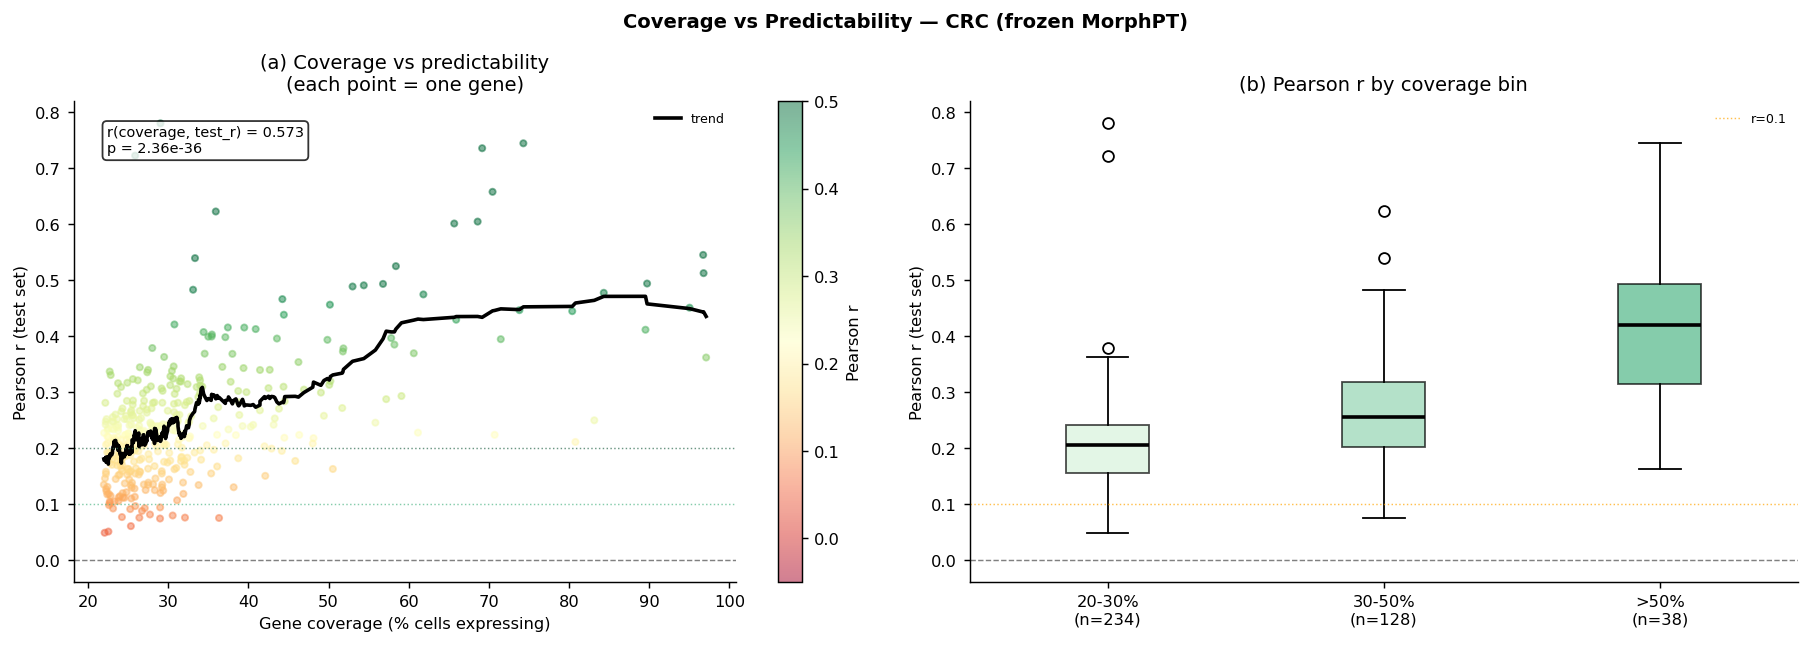


Correlation between coverage and predictability:
  Pearson r = 0.5735  p = 2.36e-36
  → Higher coverage genes are more predictable (as expected)


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Scatter: coverage vs test_r
ax = axes[0]
sc = ax.scatter(df['coverage'] * 100, df['test_r'],
                c=df['test_r'], cmap='RdYlGn',
                vmin=-0.05, vmax=0.5,
                alpha=0.5, s=12, rasterized=True)
plt.colorbar(sc, ax=ax, label='Pearson r')

# Smooth trend line
from scipy.ndimage import uniform_filter1d
sort_idx = np.argsort(df['coverage'].values)
window   = max(5, len(df)//15)
smooth   = uniform_filter1d(df['test_r'].values[sort_idx], size=window)
ax.plot(df['coverage'].values[sort_idx] * 100, smooth,
        color='black', lw=2, label='trend')

ax.axhline(0,   color='gray', lw=0.8, ls='--')
ax.axhline(0.1, color='#52b788', lw=0.8, ls=':', alpha=0.7)
ax.axhline(0.2, color='#2d6a4f', lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel('Gene coverage (% cells expressing)')
ax.set_ylabel('Pearson r (test set)')
ax.set_title('(a) Coverage vs predictability\n(each point = one gene)')
ax.legend(fontsize=7)

# Compute Pearson correlation between coverage and test_r
r_corr, p_val = stats.pearsonr(df['coverage'], df['test_r'])
ax.text(0.05, 0.95,
        f'r(coverage, test_r) = {r_corr:.3f}\np = {p_val:.2e}',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# (b) Box plot by coverage bin
ax = axes[1]
bin_data   = []
bin_labels = []
for i in range(len(blabels)):
    mask = (df['coverage'] >= bins[i]) & (df['coverage'] < bins[i+1])
    sub  = df[mask]['test_r'].values
    if len(sub) > 0:
        bin_data.append(sub)
        bin_labels.append(f"{blabels[i]}\n(n={len(sub)})")

bp = ax.boxplot(bin_data, labels=bin_labels, patch_artist=True,
                medianprops=dict(color='black', lw=2))
colors = ['#d8f3dc', '#95d5b2', '#52b788', '#2d6a4f']
for patch, col in zip(bp['boxes'], colors[:len(bin_data)]):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

ax.axhline(0,   color='gray', lw=0.8, ls='--')
ax.axhline(0.1, color='orange', lw=0.8, ls=':', alpha=0.7, label='r=0.1')
ax.set_ylabel('Pearson r (test set)')
ax.set_title('(b) Pearson r by coverage bin')
ax.legend(fontsize=7)

fig.suptitle('Coverage vs Predictability — CRC (frozen MorphPT)',
             fontweight='bold')
fig.tight_layout()
plt.show()

print(f'\nCorrelation between coverage and predictability:')
print(f'  Pearson r = {r_corr:.4f}  p = {p_val:.2e}')
if r_corr > 0.3:
    print(f'  → Higher coverage genes are more predictable (as expected)')

## 7. Val vs Test Consistency

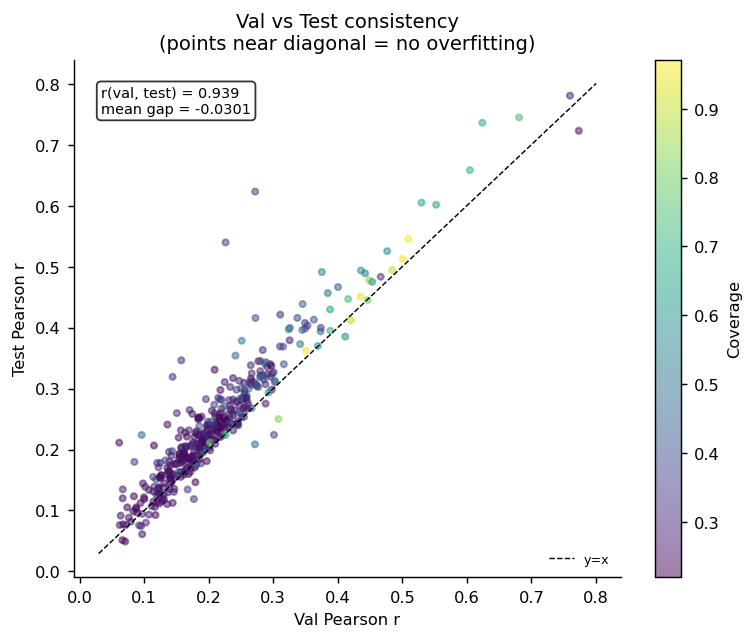

Val/Test r correlation: 0.9388
Mean val-test gap:      -0.0301


In [22]:
if 'val_r' in df.columns:
    fig, ax = plt.subplots(figsize=(6, 5))

    sc = ax.scatter(df['val_r'], df['test_r'],
                    c=df['coverage'], cmap='viridis',
                    alpha=0.5, s=12, rasterized=True)
    plt.colorbar(sc, ax=ax, label='Coverage')

    lim = [min(df['val_r'].min(), df['test_r'].min()) - 0.02,
           max(df['val_r'].max(), df['test_r'].max()) + 0.02]
    ax.plot(lim, lim, 'k--', lw=0.8, label='y=x')

    r_vt, _ = stats.pearsonr(df['val_r'], df['test_r'])
    gap     = (df['val_r'] - df['test_r']).mean()

    ax.text(0.05, 0.95,
            f'r(val, test) = {r_vt:.3f}\nmean gap = {gap:+.4f}',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel('Val Pearson r')
    ax.set_ylabel('Test Pearson r')
    ax.set_title('Val vs Test consistency\n(points near diagonal = no overfitting)')
    ax.legend(fontsize=7)

    fig.tight_layout()
    plt.show()

    print(f'Val/Test r correlation: {r_vt:.4f}')
    print(f'Mean val-test gap:      {gap:+.4f}')
    if abs(gap) < 0.02:
        print('→ Very consistent, no significant overfitting')
    elif gap > 0.05:
        print('→ Val > Test gap is large, possible overfitting')

## 8. Summary Report

In [24]:
print('=' * 65)
print('SUMMARY REPORT')
print('=' * 65)
print()
print('Experiment:')
print('  - 400 CRC genes (top coverage from spatial-split train set)')
print('  - Frozen MorphPT (original classification checkpoint)')
print('  - Features: 768-dim gate-fused embedding (2.5× + 10× H&E patches)')
print('  - Gate weights: frozen (from original MorphPT classification checkpoint)')
print('  - Head: MLP(768→256→1) trained per gene')
print('  - Evaluation: Spatial split test set')
print()
print('Results:')
print(f'  Genes evaluated   : {len(df)} / 400')
print(f'  Mean Pearson r    : {df["test_r"].mean():.4f}')
print(f'  Median Pearson r  : {df["test_r"].median():.4f}')
print(f'  Genes r > 0.1     : {(df["test_r"]>0.1).sum()} / {len(df)} ({(df["test_r"]>0.1).mean():.1%})')
print(f'  Genes r > 0.2     : {(df["test_r"]>0.2).sum()} / {len(df)} ({(df["test_r"]>0.2).mean():.1%})')
print(f'  Genes r > 0.3     : {(df["test_r"]>0.3).sum()} / {len(df)} ({(df["test_r"]>0.3).mean():.1%})')
print()

# Best predicted genes
top50= df.nlargest(50, 'test_r')[['gene_name', 'coverage', 'test_r']]
print('Top 50 predicted genes:')
for _, row in top50.iterrows():
    print(f'  {row["gene_name"]:<15} coverage={row["coverage"]:.2f}  r={row["test_r"]:.4f}')

print()
print('Key findings:')

r_corr, p_val = stats.pearsonr(df['coverage'], df['test_r'])
print(f'  1. Coverage-predictability correlation: r={r_corr:.3f} (p={p_val:.2e})')
pct_positive = (df['test_r'] > 0).mean()
print(f'  2. {pct_positive:.1%} of genes have positive Pearson r')
print(f'     → Frozen MorphPT features contain real gene expression signal')

best_gene = df.nlargest(1, 'test_r').iloc[0]
print(f'  3. Best gene: {best_gene["gene_name"]} (r={best_gene["test_r"]:.4f}, coverage={best_gene["coverage"]:.2f})')

# Save summary
df.to_csv(MLP_EXP_DIR / 'summary.csv', index=False)
print(f'\nFull results saved → {MLP_EXP_DIR}/summary.csv')

SUMMARY REPORT

Experiment:
  - 400 CRC genes (top coverage from spatial-split train set)
  - Frozen MorphPT (original classification checkpoint)
  - Features: 768-dim gate-fused embedding (2.5× + 10× H&E patches)
  - Gate weights: frozen (from original MorphPT classification checkpoint)
  - Head: MLP(768→256→1) trained per gene
  - Evaluation: Spatial split test set

Results:
  Genes evaluated   : 400 / 400
  Mean Pearson r    : 0.2454
  Median Pearson r  : 0.2274
  Genes r > 0.1     : 383 / 400 (95.8%)
  Genes r > 0.2     : 258 / 400 (64.5%)
  Genes r > 0.3     : 91 / 400 (22.8%)

Top 50 predicted genes:
  VIM             coverage=0.29  r=0.7805
  CEACAM5         coverage=0.74  r=0.7448
  CEACAM6         coverage=0.69  r=0.7361
  COL3A1          coverage=0.26  r=0.7229
  MUC12           coverage=0.70  r=0.6582
  IGKC            coverage=0.36  r=0.6231
  EPCAM           coverage=0.69  r=0.6050
  PYGB            coverage=0.66  r=0.6016
  MT-ND4          coverage=0.97  r=0.5455
  LCN2  